## Importing Libraries

In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

In [53]:
import warnings
warnings.filterwarnings("ignore")
from scipy.stats import ttest_ind, mannwhitneyu

# Plot & Display settings
plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (10,6)
plt.rcParams["font.size"] = 12

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 20)
print("Libraries imported successfully.")

Libraries imported successfully.


## Loading Datasets

In [54]:
fear_greed = pd.read_csv("fear_greed_index.csv")
trades = pd.read_csv("historical_data.csv")

print("Fear & Greed Shape :", fear_greed.shape)
print("Historical Trades Shape :", trades.shape)

Fear & Greed Shape : (2644, 4)
Historical Trades Shape : (211224, 16)


In [55]:
fear_greed.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [56]:
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


## Statistical Info
Focuses on: Dataset dimensions,
Data types,
Missing values,
Duplicate records,
Basic descriptive statistics.

In [57]:
def data_info(df, name):
    print(name)
    print("-"*20)
    print(f"Shape : {df.shape}")

    print("\nData Types")
    print(df.dtypes)

    print("\nMissing Values")
    print(df.isnull().sum())

    print("\nDuplicate Rows")
    print(df.duplicated().sum())

    print("\nSummary Statistics")
    display(df.describe(include="all"))

In [58]:
data_info(fear_greed, "Fear & Greed Dataset") #dataset_1 (Classifications has 5 unique values)

Fear & Greed Dataset
--------------------
Shape : (2644, 4)

Data Types
timestamp         int64
value             int64
classification      str
date                str
dtype: object

Missing Values
timestamp         0
value             0
classification    0
date              0
dtype: int64

Duplicate Rows
0

Summary Statistics


,timestamp,value,classification,date
count,2.644000e+03,2644.000000,2644,2644
unique,NaN,NaN,5,2644
top,NaN,NaN,Fear,2018-02-01
freq,NaN,NaN,781,1
mean,1.631899e+09,46.981089,NaN,NaN
std,6.597967e+07,21.827680,NaN,NaN
min,1.517463e+09,5.000000,NaN,NaN
25%,1.574811e+09,28.000000,NaN,NaN
50%,1.631900e+09,46.000000,NaN,NaN
75%,1.688989e+09,66.000000,NaN,NaN


In [59]:
fear_greed["classification"].value_counts()

classification
Fear             781
Greed            633
Extreme Fear     508
Neutral          396
Extreme Greed    326
Name: count, dtype: int64

In [60]:
data_info(trades, "Historical Dataset")  #dataset_2

Historical Dataset
--------------------
Shape : (211224, 16)

Data Types
Account                 str
Coin                    str
Execution Price     float64
Size Tokens         float64
Size USD            float64
Side                    str
Timestamp IST           str
Start Position      float64
Direction               str
Closed PnL          float64
Transaction Hash        str
Order ID              int64
Crossed                bool
Fee                 float64
Trade ID            float64
Timestamp           float64
dtype: object

Missing Values
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

Duplicate Rows
0

Summary Statistics


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
count,211224,211224,211224.000000,2.112240e+05,2.112240e+05,211224,211224,2.112240e+05,211224,211224.000000,211224,2.112240e+05,211224,211224.000000,2.112240e+05,2.112240e+05
unique,32,246,NaN,NaN,NaN,2,27977,NaN,12,NaN,101184,NaN,2,NaN,NaN,NaN
top,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,HYPE,NaN,NaN,NaN,SELL,14-02-2025 00:31,NaN,Open Long,NaN,0x00000000000000000000000000000000000000000000...,NaN,True,NaN,NaN,NaN
freq,40184,68005,NaN,NaN,NaN,108528,441,NaN,49895,NaN,9032,NaN,128403,NaN,NaN,NaN
mean,NaN,NaN,11414.723350,4.623365e+03,5.639451e+03,NaN,NaN,-2.994625e+04,NaN,48.749001,NaN,6.965388e+10,NaN,1.163967,5.628549e+14,1.737744e+12
std,NaN,NaN,29447.654868,1.042729e+05,3.657514e+04,NaN,NaN,6.738074e+05,NaN,919.164828,NaN,1.835753e+10,NaN,6.758854,3.257565e+14,8.689920e+09
min,NaN,NaN,0.000005,8.740000e-07,0.000000e+00,NaN,NaN,-1.433463e+07,NaN,-117990.104100,NaN,1.732711e+08,NaN,-1.175712,0.000000e+00,1.680000e+12
25%,NaN,NaN,4.854700,2.940000e+00,1.937900e+02,NaN,NaN,-3.762311e+02,NaN,0.000000,NaN,5.983853e+10,NaN,0.016121,2.810000e+14,1.740000e+12
50%,NaN,NaN,18.280000,3.200000e+01,5.970450e+02,NaN,NaN,8.472793e+01,NaN,0.000000,NaN,7.442939e+10,NaN,0.089578,5.620000e+14,1.740000e+12
75%,NaN,NaN,101.580000,1.879025e+02,2.058960e+03,NaN,NaN,9.337278e+03,NaN,5.792797,NaN,8.335543e+10,NaN,0.393811,8.460000e+14,1.740000e+12


## Data Cleaning
The dataset has no missing or duplicate values, now creating standardised data types and a common "DAILY DATE" field for merging between sentiment and trading activity.

* Converted date columns to datetime format.
* Created a daily trade date from transaction timestamps.
* Verified date ranges between datasets.

In [61]:
#changing date as it is a string now
fear_greed["date"] = pd.to_datetime(fear_greed["date"])
print("Fear & Greed Date Range")
print(fear_greed["date"].min())
print(fear_greed["date"].max())

Fear & Greed Date Range
2018-02-01 00:00:00
2025-05-02 00:00:00


In [62]:
#for historical dataset
trades["Timestamp IST"] = pd.to_datetime(trades["Timestamp IST"],format="%d-%m-%Y %H:%M")

In [63]:
trades["Trade Date"] = trades["Timestamp IST"].dt.normalize()
print("Historical Data Date Range")
print(trades["Trade Date"].min())
print(trades["Trade Date"].max())

Historical Data Date Range
2023-05-01 00:00:00
2025-05-01 00:00:00


## Feature Engineering
Data Alignment & Aggregation

Since the trading data is recorded for every individual trade and the sentiment data is available by date, the trading data is aggregated to daily trader-level metrics. This allows both datasets to be merged and compared on the same time scale.

In [64]:
#Trade Outcomes
trades["Win"] = (trades["Closed PnL"] > 0).astype(int)
trades["Loss"] = (trades["Closed PnL"] < 0).astype(int)

In [65]:
daily_metrics = (
    trades.groupby(["Trade Date", "Account"])
    .agg(
        Daily_PnL=("Closed PnL", "sum"),
        Total_Trades=("Account", "count"),
        Winning_Trades=("Closed PnL", lambda x: (x > 0).sum()),
        Avg_Trade_Size=("Size USD", "mean"),
        Total_Volume=("Size USD", "sum"),
        Total_Fees=("Fee","sum"),
        Avg_Fee=("Fee", "mean"),
        Long_Trades=("Direction", lambda x: x.str.contains("Long").sum()),
        Short_Trades=("Direction", lambda x: x.str.contains("Short").sum())
    )
    .reset_index()
)

In [66]:
daily_metrics["Win_Rate"] = (daily_metrics["Winning_Trades"] / daily_metrics["Total_Trades"])

daily_metrics["Long_Ratio"] = (daily_metrics["Long_Trades"] / daily_metrics["Total_Trades"])

daily_metrics["Short_Ratio"] = (daily_metrics["Short_Trades"] / daily_metrics["Total_Trades"])

daily_metrics["Profit_per_Trade"] = (daily_metrics["Daily_PnL"] / daily_metrics["Total_Trades"])

In [67]:
daily_metrics.head()

,Trade Date,Account,Daily_PnL,Total_Trades,Winning_Trades,Avg_Trade_Size,Total_Volume,Total_Fees,Avg_Fee,Long_Trades,Short_Trades,Win_Rate,Long_Ratio,Short_Ratio,Profit_per_Trade
0,2023-05-01,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0.000000,3,0,159.000000,477.00,0.000000,0.000000,3,0,0.000000,1.000000,0.000000,0.000000
1,2023-12-05,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.000000,9,0,5556.203333,50005.83,12.501455,1.389051,7,2,0.000000,0.777778,0.222222,0.000000
2,2023-12-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,-205.434737,11,4,10291.213636,113203.35,28.300831,2.572803,7,4,0.363636,0.636364,0.363636,-18.675885
3,2023-12-15,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,-24.632034,2,0,5304.975000,10609.95,2.652489,1.326245,0,2,0.000000,0.000000,1.000000,-12.316017
4,2023-12-16,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.000000,3,0,5116.256667,15348.77,3.837189,1.279063,3,0,0.000000,1.000000,0.000000,0.000000


In [68]:
summary = daily_metrics.describe().T
summary[["mean", "std", "min", "50%", "max"]]

,mean,std,min,50%,max
Trade Date,2024-12-22 00:49:49.491670,NaN,2023-05-01 00:00:00,2025-01-28 00:00:00,2025-05-01 00:00:00
Daily_PnL,4398.530091,28415.938999,-358963.139984,207.983482,533974.662903
Total_Trades,90.228108,214.611751,1.0,29.0,4083.0
Winning_Trades,37.107646,102.565107,0.0,7.0,1824.0
Avg_Trade_Size,6989.515321,21538.691665,0.0,1914.0,844654.19
Total_Volume,508837.010876,2413745.029566,0.0,69357.39,51250451.44
Total_Fees,105.022521,461.394026,-4.847684,13.705607,10554.753586
Avg_Fee,1.566612,2.92323,-0.092558,0.344985,42.232709
Long_Trades,42.161469,169.12268,0.0,3.0,4083.0
Short_Trades,32.414353,95.81787,0.0,3.0,1948.0


In [69]:
trades["Direction"].value_counts()

Direction
Open Long                    49895
Close Long                   48678
Open Short                   39741
Close Short                  36013
Sell                         19902
Buy                          16716
Spot Dust Conversion           142
Short > Long                    70
Long > Short                    57
Auto-Deleveraging                8
Liquidated Isolated Short        1
Settlement                       1
Name: count, dtype: int64

In [70]:
trades["Coin"].value_counts().head(10)

Coin
HYPE         68005
@107         29992
BTC          26064
ETH          11158
SOL          10691
FARTCOIN      4650
MELANIA       4428
PURR/USDC     2774
WLD           1983
SUI           1979
Name: count, dtype: int64

In [71]:
#Merging dataset
merged = daily_metrics.merge(
    fear_greed,
    left_on="Trade Date",
    right_on="date",
    how="left"
)

In [72]:
print (f"Merged dataset shape: {merged.shape}")
merged.head()

Merged dataset shape: (2341, 19)


,Trade Date,Account,Daily_PnL,Total_Trades,Winning_Trades,Avg_Trade_Size,Total_Volume,Total_Fees,Avg_Fee,Long_Trades,Short_Trades,Win_Rate,Long_Ratio,Short_Ratio,Profit_per_Trade,timestamp,value,classification,date
0,2023-05-01,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0.000000,3,0,159.000000,477.00,0.000000,0.000000,3,0,0.000000,1.000000,0.000000,0.000000,1.682919e+09,63.0,Greed,2023-05-01
1,2023-12-05,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.000000,9,0,5556.203333,50005.83,12.501455,1.389051,7,2,0.000000,0.777778,0.222222,0.000000,1.701754e+09,75.0,Extreme Greed,2023-12-05
2,2023-12-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,-205.434737,11,4,10291.213636,113203.35,28.300831,2.572803,7,4,0.363636,0.636364,0.363636,-18.675885,1.702532e+09,72.0,Greed,2023-12-14
3,2023-12-15,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,-24.632034,2,0,5304.975000,10609.95,2.652489,1.326245,0,2,0.000000,0.000000,1.000000,-12.316017,1.702618e+09,70.0,Greed,2023-12-15
4,2023-12-16,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.000000,3,0,5116.256667,15348.77,3.837189,1.279063,3,0,0.000000,1.000000,0.000000,0.000000,1.702705e+09,67.0,Greed,2023-12-16


In [73]:
merged["classification"].value_counts()

classification
Greed            648
Fear             630
Extreme Greed    526
Neutral          376
Extreme Fear     160
Name: count, dtype: int64

# Part B — Exploratory Data Analysis
The objective of this section is to examine whether market sentiment influences trader performance and trading behavior.

##### Q1 Does performance (PnL, Win Rate, Drawdown Proxy) differ between Fear vs Greed days?

In [74]:
merged_2 = merged.copy()

In [75]:
# Combining sentiments into Fear vs Greed

merged_2["Sentiment"] = merged_2["classification"].replace({
    "Extreme Fear": "Fear",
    "Fear": "Fear",
    "Extreme Greed": "Greed",
    "Greed": "Greed"
})

In [76]:
performance_df = merged_2[merged_2["Sentiment"] != "Neutral"].copy()

In [77]:
performance_summary = (
    performance_df.groupby("Sentiment").agg(
        Average_PnL=("Daily_PnL", "mean"),
        Median_PnL=("Daily_PnL", "median"),
        Average_Win_Rate=("Win_Rate", "mean"),
        Average_Trades=("Total_Trades", "mean"),
        Average_Trade_Size=("Avg_Trade_Size", "mean")
    )
    .round(2)
)

performance_summary

,Average_PnL,Median_PnL,Average_Win_Rate,Average_Trades,Average_Trade_Size
Sentiment,,,,,
Fear,5185.15,122.74,0.36,105.36,8529.86
Greed,4144.21,265.25,0.36,76.91,5954.63


# Plotting the visuals

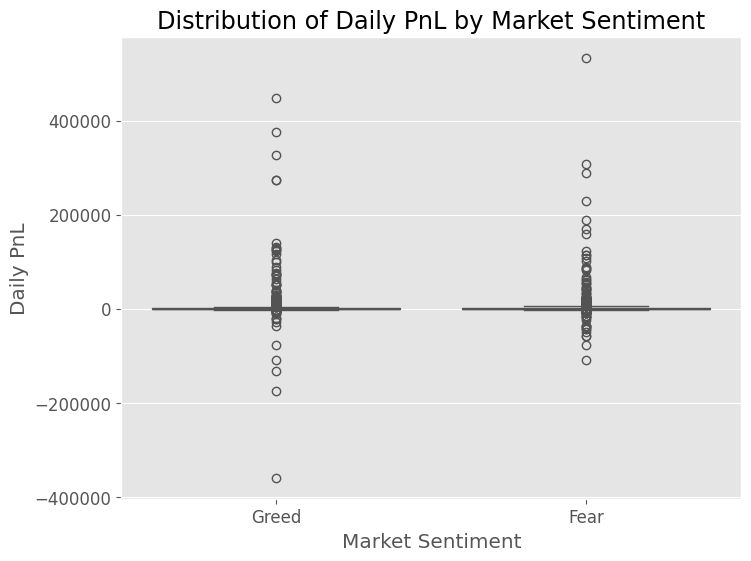

In [78]:
plt.figure(figsize=(8,6))
sns.boxplot(
    data=performance_df,
    x="Sentiment",
    y="Daily_PnL")
plt.title("Distribution of Daily PnL by Market Sentiment")
save_chart("Distribution of Daily PnL by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Daily PnL")
plt.show()

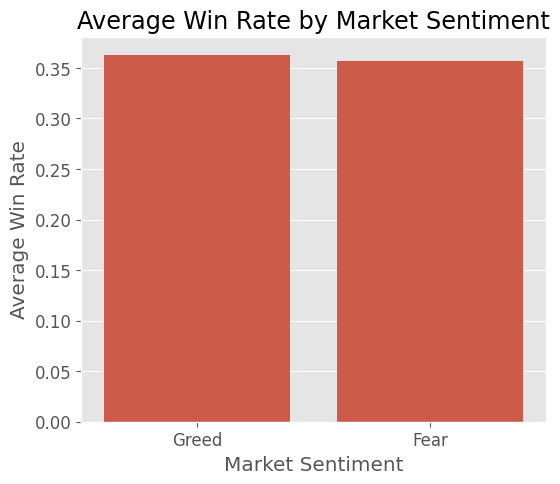

In [79]:
plt.figure(figsize=(6,5))

sns.barplot(
    data=performance_df,
    x="Sentiment",
    y="Win_Rate",
    estimator=np.mean,
    errorbar=None)
plt.title("Average Win Rate by Market Sentiment")
save_chart("Average Win Rate by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Win Rate")
plt.show()

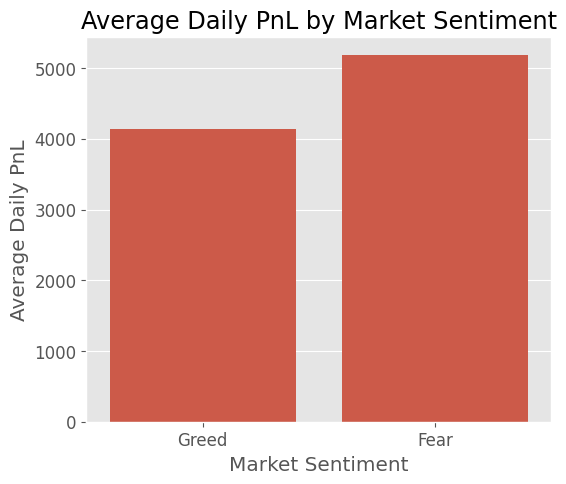

In [80]:
plt.figure(figsize=(6,5))

sns.barplot(
    data=performance_df,
    x="Sentiment",
    y="Daily_PnL",
    estimator=np.mean,
    errorbar=None)
plt.title("Average Daily PnL by Market Sentiment")
save_chart("Average Daily PnL by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Daily PnL")
plt.show()


## Key Findings

* Traders had a higher average daily PnL during Fear days than during Greed days.
* However, the median PnL was higher during Greed days, which suggests that a few very profitable trades during Fear increased the overall average.
* The average win rate remained almost the same (36%) in both market conditions.
* The boxplot shows that Fear days have a wider spread of PnL values, indicating more variation in trader performance than Greed days.


### Q2 Do traders change behaviour based on sentiment?

###### The provided dataset does not contain an explicit leverage column. Therefore, leverage-based analysis could not be performed.

In [81]:
# Trade frequency summary table
trade_freq_summary = (performance_df.groupby("Sentiment").agg(Average_Trades=("Total_Trades","mean"),Median_Trades=("Total_Trades","median"))
    .round(2))
trade_freq_summary

,Average_Trades,Median_Trades
Sentiment,,
Fear,105.36,31.0
Greed,76.91,28.0


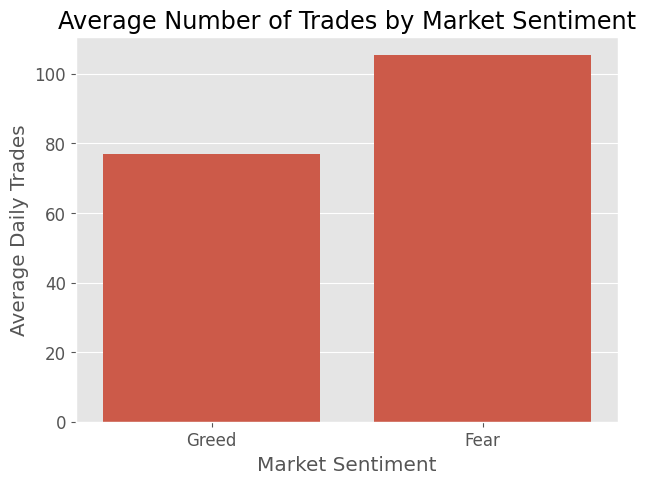

In [82]:
#Plotting
plt.figure(figsize=(7,5))
sns.barplot(
    data=performance_df,
    x="Sentiment",
    y="Total_Trades",
    estimator=np.mean,
    errorbar=None
)
plt.title("Average Number of Trades by Market Sentiment")
save_chart("Average Number of Trades by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Daily Trades")
plt.show()

In [83]:
#Position Size
position_summary = (performance_df.groupby("Sentiment").agg(Average_Trade_Size=("Avg_Trade_Size","mean"),
    Median_Trade_Size=("Avg_Trade_Size","median")
    )
    .round(2))
position_summary

,Average_Trade_Size,Median_Trade_Size
Sentiment,,
Fear,8529.86,1853.68
Greed,5954.63,2004.69


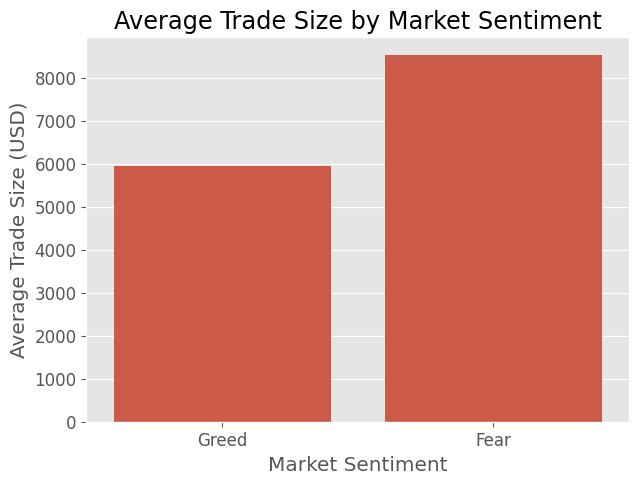

In [84]:
plt.figure(figsize=(7,5))
sns.barplot(
    data=performance_df,
    x="Sentiment",
    y="Avg_Trade_Size",
    estimator=np.mean,
    errorbar=None)

plt.title("Average Trade Size by Market Sentiment")
save_chart("Average Trade Size by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Trade Size (USD)")

plt.show()

In [85]:
#long / Short Bias
bias_summary = (performance_df.groupby("Sentiment").agg(Average_Long_Ratio=("Long_Ratio","mean"),Average_Short_Ratio=("Short_Ratio","mean"))
    .round(2))
bias_summary

,Average_Long_Ratio,Average_Short_Ratio
Sentiment,,
Fear,0.47,0.36
Greed,0.37,0.39


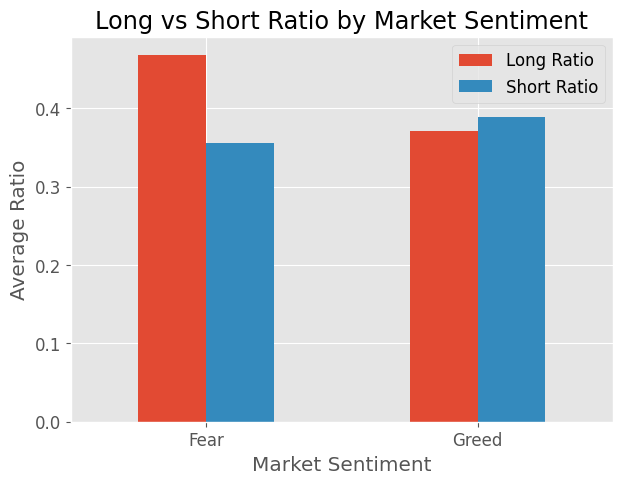

In [86]:
#Plotting long/ short bias
bias_plot = (performance_df.groupby("Sentiment")[["Long_Ratio","Short_Ratio"]].mean().reset_index())
bias_plot.plot(x="Sentiment",kind="bar",figsize=(7,5))
plt.title("Long vs Short Ratio by Market Sentiment")
save_chart("Long vs Short Ratio by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Ratio")
plt.xticks(rotation=0)
plt.legend(["Long Ratio","Short Ratio"])
plt.show()

## Key Findings

* Trade Frequency: Traders executed more trades during Fear (105.36) than Greed (76.91), indicating higher trading activity.
* Position Size: The average trade size was higher during Fear, although the slightly higher median during Greed suggests Fear had a few unusually large trades.
* Long/Short Bias: Traders showed a stronger long bias during Fear (0.47 vs. 0.36), while Greed periods had a more balanced long/short distribution (0.37 vs. 0.39).

Overall: The results indicate that traders changed their trading activity, position sizing, and directional bias based on market sentiment.

# Frequent vs Infrequent Traders

In [87]:
trade_threshold = daily_metrics["Total_Trades"].median()
daily_metrics["Trader_Segment"] = np.where(daily_metrics["Total_Trades"] >= trade_threshold,"Frequent","Infrequent")

In [88]:
segment_summary = (daily_metrics.groupby("Trader_Segment").agg(
        Average_PnL=("Daily_PnL","mean"),
        Average_Win_Rate=("Win_Rate","mean"),
        Average_Trades=("Total_Trades","mean")).round(2))
segment_summary

,Average_PnL,Average_Win_Rate,Average_Trades
Trader_Segment,,,
Frequent,7457.48,0.41,168.00
Infrequent,1273.54,0.31,10.78


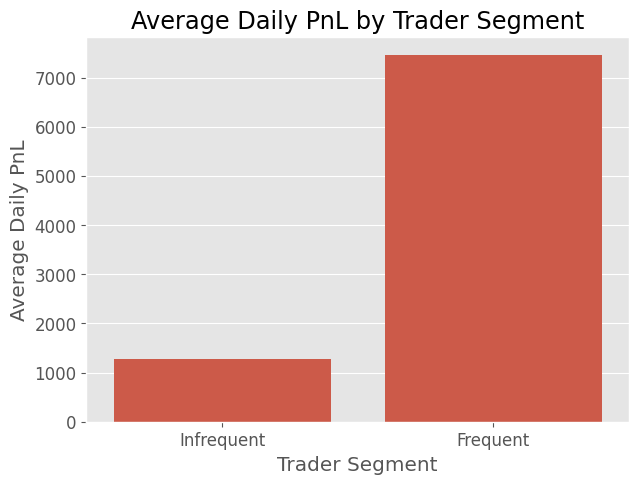

In [89]:
plt.figure(figsize=(7,5))
sns.barplot(
    data=daily_metrics,
    x="Trader_Segment",
    y="Daily_PnL",
    estimator=np.mean,
    errorbar=None)
plt.title("Average Daily PnL by Trader Segment")
save_chart("Average Daily PnL by Trader Segment")
plt.xlabel("Trader Segment")
plt.ylabel("Average Daily PnL")
plt.show()

# Consistent vs Inconsistent Traders

In [90]:
daily_metrics["Performance_Segment"] = np.where(daily_metrics["Win_Rate"] >= 0.50,"Consistent Winner","Inconsistent")

In [91]:
winner_summary = (daily_metrics.groupby("Performance_Segment").agg(
        Average_PnL=("Daily_PnL","mean"),
        Average_Win_Rate=("Win_Rate","mean"),
        Average_Trades=("Total_Trades","mean")).round(2))
winner_summary

,Average_PnL,Average_Win_Rate,Average_Trades
Performance_Segment,,,
Consistent Winner,11206.70,0.78,89.05
Inconsistent,1074.51,0.15,90.80


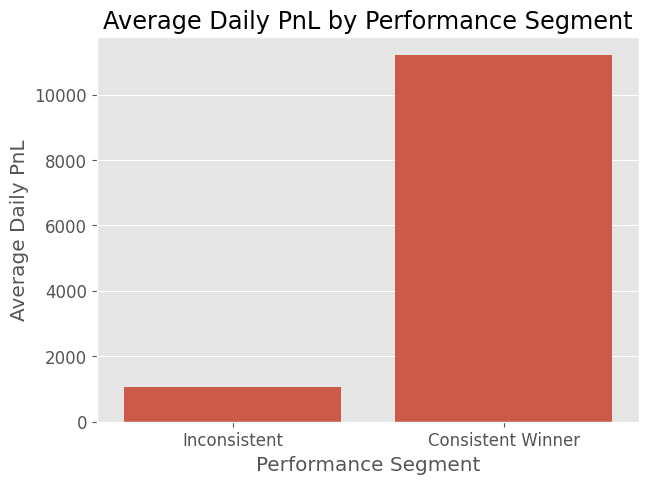

In [92]:
plt.figure(figsize=(7,5))
sns.barplot(
    data=daily_metrics,
    x="Performance_Segment",
    y="Daily_PnL",
    estimator=np.mean,
    errorbar=None)
plt.title("Average Daily PnL by Performance Segment")
save_chart("Average Daily PnL by Performance Segment")
plt.xlabel("Performance Segment")
plt.ylabel("Average Daily PnL")
plt.show()

# Evidence-based strategy recommendations:

* During Fear periods, prioritize selective long trades instead of increasing trade frequency, as traders were already more active with larger position sizes but not higher win rates.
* Frequent and consistent-winning traders can maintain higher trading activity, while infrequent or inconsistent traders should focus on improving win rate before increasing the number of trades.


#### These recommendations are directly supported by:
* Higher trading activity and larger average trade sizes during Fear.
* Similar win rates across Fear and Greed.
* Frequent traders having much higher average PnL (7457 vs. 1274).
* Consistent winners achieving substantially higher average PnL (11207 vs. 1075).

### To save the charts as PNG file

In [93]:
import os
os.makedirs("charts", exist_ok=True)
def save_chart(filename):
    plt.savefig(
        f"charts/{filename}.png",
        dpi=300,
        bbox_inches="tight"
    )

# Project Summary

## Methodology

The analysis began with data inspection and cleaning for both the Fear & Greed Index and historical trading datasets. Date columns were converted into a common datetime format and the trading data was aggregated into daily trader-level metrics such as Daily PnL, Win Rate, Total Trades, Trade Size, Trading Volume, and Long Ratio. The aggregated trading data was then merged with the daily Fear & Greed Index to analyze trading performance under different market sentiment conditions. Finally, traders were segmented based on trading frequency and performance consistency to compare behavioural patterns.

## Key Insights

* Traders generated a higher average Daily PnL during Fear periods, while the median PnL was higher during Greed, indicating that a few exceptionally profitable trades increased the average during Fear.
* Trading activity was higher during Fear periods, with traders executing more trades and using larger average position sizes than during Greed.
* Frequent traders produced substantially higher average profits than infrequent traders, while consistent winners significantly outperformed inconsistent traders despite similar trading activity.

## Strategy Recommendations

* During Fear periods, traders should prioritize disciplined position sizing instead of increasing trading activity, as higher activity did not correspond to higher win rates.
* Frequent and consistent traders may continue higher trading activity, while less consistent traders should focus on improving trade quality and win rate before increasing trade frequency.
